# Practical Statistics for Data Scientists — Chapter 1: Exploratory Data Analysis (EDA)

## 📌 Ringkasan Bab

**Exploratory Data Analysis (EDA)** adalah langkah pertama dalam setiap proyek data science: *"kenalan dulu dengan datanya sebelum membuat model."* Bab ini diperkenalkan oleh statistikawan John Tukey (1977) yang menekankan bahwa kita harus **melihat data** (lewat angka ringkasan dan grafik) sebelum melakukan pemodelan atau pengujian formal.

Yang dibahas di bab ini:

| Topik | Pertanyaan yang dijawab |
|---|---|
| Estimates of Location | Di mana "pusat" data? (mean, median, trimmed mean) |
| Estimates of Variability | Seberapa menyebar data? (variance, std, MAD, IQR) |
| Distribusi data | Bentuk sebaran data? (boxplot, histogram, density) |
| Data biner & kategorikal | Bagaimana meringkas data kategori? (mode, proporsi) |
| Korelasi | Apakah dua variabel bergerak bersama? |
| Dua variabel atau lebih | Bagaimana melihat hubungan antar variabel? (hexbin, contour, violin, tabel kontingensi) |

**Mengapa penting?** Karena data nyata hampir selalu punya *outlier*, nilai hilang, dan distribusi yang miring. Kalau langsung dimodelkan tanpa EDA, hasilnya bisa menyesatkan.

**Istilah penting:** *Metric/statistic* = angka ringkasan dari data · *Robust* = tidak mudah terpengaruh outlier · *Outlier* = nilai ekstrem yang jauh dari mayoritas data.


## 🛠️ Setup & Import Library

Sel di bawah meng-install **wquantiles** (untuk median berbobot), lalu mengimpor library yang dipakai:

| Library | Fungsi di notebook ini |
|---|---|
| `pandas` | Membaca CSV dan mengolah tabel (DataFrame) |
| `numpy` | Operasi numerik, termasuk rata-rata berbobot |
| `scipy.stats.trim_mean` | Menghitung *trimmed mean* |
| `statsmodels.robust` | Menghitung MAD (*median absolute deviation*) |
| `wquantiles` | Median berbobot (*weighted median*) |
| `seaborn`, `matplotlib` | Visualisasi (heatmap, KDE, violin, boxplot, dll.) |

In [1]:
pip install wquantiles

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Note: you may need to restart the kernel to use updated packages.


In [2]:
%matplotlib inline

from pathlib import Path

import pandas as pd
import numpy as np
from scipy.stats import trim_mean
from statsmodels import robust
import wquantiles

import seaborn as sns
import matplotlib.pylab as plt

## 📂 Dataset Awal: `state.csv`

Berisi **50 negara bagian AS** dengan kolom `Population` (jumlah penduduk, sensus 2010), `Murder.Rate` (kasus pembunuhan per 100.000 penduduk), dan `Abbreviation` (singkatan negara bagian). Kita pakai untuk mempraktikkan ukuran pemusatan dan penyebaran (Tabel 1-2 di buku).

In [3]:
# Table 1-2
state = pd.read_csv('state.csv')
print(state.head(8))

         State  Population  Murder.Rate Abbreviation
0      Alabama     4779736          5.7           AL
1       Alaska      710231          5.6           AK
2      Arizona     6392017          4.7           AZ
3     Arkansas     2915918          5.6           AR
4   California    37253956          4.4           CA
5     Colorado     5029196          2.8           CO
6  Connecticut     3574097          2.4           CT
7     Delaware      897934          5.8           DE


## 📍 Estimates of Location (Ukuran Pemusatan)

Tujuannya: **meringkas data dengan satu angka yang mewakili "nilai tengah"**.

| Ukuran | Rumus / Cara | Kelebihan | Kekurangan |
|---|---|---|---|
| **Mean** | $\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$ | Mudah dihitung, umum dipakai | **Sangat sensitif terhadap outlier** |
| **Trimmed mean** | Buang $p\%$ data terkecil & terbesar, lalu rata-ratakan | Lebih tahan outlier | Perlu memilih $p$ |
| **Weighted mean** | $\bar{x}_w = \frac{\sum w_i x_i}{\sum w_i}$ | Bisa memberi bobot berbeda | Perlu menentukan bobot |
| **Median** | Nilai tengah setelah data diurutkan | **Robust** terhadap outlier | Tidak memakai semua informasi data |
| **Weighted median** | Median dengan bobot | Robust + berbobot | — |

**Contoh sederhana:** gaji 5 orang = 5, 6, 7, 8, 1000 (juta). Mean = 205 juta (tidak mewakili siapa pun!), median = 7 juta (lebih masuk akal).

**Di bawah ini** kita menghitung mean, trimmed mean, dan median **populasi per negara bagian AS**. Perhatikan bahwa mean lebih besar dari median karena beberapa negara bagian (California, Texas) berpopulasi sangat besar → distribusi **miring ke kanan (right-skewed)**.

#### ✂️ Trimmed Mean (Rata-rata Terpangkas)

**Ide:** buang sebagian nilai paling kecil dan paling besar, lalu rata-ratakan sisanya, sehingga nilai ekstrem tidak terlalu memengaruhi hasil.

**Analogi:** dalam penilaian lomba loncat indah, nilai tertinggi dan terendah dari para juri dibuang, lalu sisanya dirata-ratakan. Tujuannya agar satu juri yang "nakal" tidak bisa memengaruhi hasil akhir.

**Rumus** (buang $p$ data terkecil dan $p$ data terbesar dari $n$ data yang sudah diurutkan):
$$ \bar{x}_{trim} = \frac{\sum_{i=p+1}^{n-p} x_{(i)}}{n-2p} $$

Pada kode di bawah, `trim_mean(..., 0.1)` membuang **10% data paling kecil dan 10% paling besar** (5 negara bagian di tiap ujung dari total 50). Trimmed mean sering dipilih sebagai kompromi antara **mean** (memakai semua data tapi sensitif outlier) dan **median** (sangat tahan outlier tapi hanya memakai data tengah).

#### ⚖️ Weighted Mean (Rata-rata Berbobot)

**Ide:** tidak semua data "sama penting". Tiap data diberi **bobot** $w_i$:
$$ \bar{x}_w = \frac{\sum_{i=1}^{n} w_i x_i}{\sum_{i=1}^{n} w_i} $$

**Dua alasan utama memakai bobot:**
1. **Keandalan data berbeda.** Contoh: rata-rata dari beberapa sensor. Sensor yang kurang akurat diberi bobot lebih kecil agar tidak merusak hasil.
2. **Data tidak mewakili semua kelompok secara seimbang.** Contoh: pada eksperimen online, kelompok pengguna yang kurang terwakili diberi bobot lebih besar agar hasil mencerminkan seluruh populasi.

**Pada contoh ini:** angka *murder rate* tiap negara bagian dibobot dengan **jumlah penduduknya**. Alasannya, rata-rata biasa memperlakukan Wyoming (penduduk sedikit) sama pentingnya dengan California (penduduk sangat banyak), padahal untuk "angka nasional" negara bagian yang penduduknya banyak seharusnya lebih berpengaruh.

Untuk median, versi berbobotnya disebut **weighted median** (dihitung dengan paket `wquantiles`).

In [4]:
print(state['Population'].mean())

6162876.3


In [5]:
print(trim_mean(state['Population'], 0.1))

4783697.125


In [6]:
print(state['Population'].median())

4436369.5


#### 🔎 Interpretasi Hasil (Populasi)

| Ukuran | Hasil | Arti |
|---|---|---|
| Mean | ≈ 6.162.876 | Rata-rata biasa |
| Trimmed mean (10%) | ≈ 4.783.697 | Lebih kecil karena negara bagian raksasa ikut terbuang |
| Median | ≈ 4.436.369 | Nilai tengah, paling tahan outlier |

**Kesimpulan:** *mean > trimmed mean > median*. Mean "tertarik" ke atas oleh beberapa negara bagian berpenduduk sangat besar (misalnya California dengan ±37 juta). Ini ciri distribusi **miring ke kanan (right-skewed)**. Untuk data seperti ini, **median lebih mewakili negara bagian "tipikal"**.

In [7]:
print(state['Murder.Rate'].mean())

4.066


In [8]:
print(np.average(state['Murder.Rate'], weights=state['Population']))

4.445833981123393


In [9]:
print(wquantiles.median(state['Murder.Rate'], weights=state['Population']))

4.4


#### 🔎 Interpretasi Hasil (Murder Rate)

| Ukuran | Hasil |
|---|---|
| Mean biasa | ≈ 4,07 |
| Weighted mean (bobot = populasi) | ≈ 4,45 |
| Weighted median | 4,4 |

Rata-rata berbobot **lebih tinggi** daripada rata-rata biasa. Artinya negara bagian berpenduduk besar cenderung punya *murder rate* yang lebih tinggi, sehingga ketika mereka diberi bobot lebih besar, rata-rata naik. Jadi pemilihan ukuran (berbobot atau tidak) **mengubah kesimpulan**, dan harus disesuaikan dengan pertanyaan yang ingin dijawab.

## 📏 Estimates of Variability (Ukuran Penyebaran)

Lokasi saja tidak cukup. Dua kelas bisa punya rata-rata nilai sama (75), tapi satu kelas nilainya 74–76 semua, kelas lain 30–100. **Variabilitas** mengukur seberapa tersebar data.

| Ukuran | Rumus | Catatan |
|---|---|---|
| **Deviation (deviasi)** | $x_i - \bar{x}$ | Selisih tiap data dengan mean |
| **Variance** | $s^2 = \frac{\sum (x_i-\bar{x})^2}{n-1}$ | Dibagi $n-1$ (*degrees of freedom*) agar tidak bias |
| **Standard deviation** | $s = \sqrt{s^2}$ | Satuannya sama dengan data asli |
| **Mean absolute deviation** | $\frac{\sum \lvert x_i-\bar{x}\rvert}{n}$ | Kurang sensitif outlier dari std |
| **Median absolute deviation (MAD)** | $\text{median}(\lvert x_i - m\rvert)$ | **Robust** |
| **Range** | max − min | Sangat sensitif outlier |
| **Percentile** | Nilai di mana $P\%$ data berada di bawahnya | |
| **IQR** | $Q_3 - Q_1$ (persentil 75 − 25) | Robust, mencakup 50% data tengah |

**Kenapa $n-1$?** Karena mean dihitung dari data yang sama, satu "derajat kebebasan" sudah terpakai. Membagi dengan $n$ akan meremehkan variansi populasi.

**Aturan praktis:** variance/std tidak robust (kuadrat memperbesar outlier). Untuk data yang punya outlier, gunakan **MAD atau IQR**.

In [10]:
print(state.head(8))

         State  Population  Murder.Rate Abbreviation
0      Alabama     4779736          5.7           AL
1       Alaska      710231          5.6           AK
2      Arizona     6392017          4.7           AZ
3     Arkansas     2915918          5.6           AR
4   California    37253956          4.4           CA
5     Colorado     5029196          2.8           CO
6  Connecticut     3574097          2.4           CT
7     Delaware      897934          5.8           DE


In [11]:
print(state['Population'].std())

6848235.347401142


In [12]:
print(state['Population'].quantile(0.75) - state['Population'].quantile(0.25))

4847308.0


In [13]:
print(robust.scale.mad(state['Population']))
print(abs(state['Population'] - state['Population'].median()).median() / 0.6744897501960817) ##0.6744897501960817 is the 75th percentile of the standard normal distribution.


3849876.1459979336
3849876.1459979336


#### 🔎 Interpretasi Hasil (Penyebaran Populasi)

| Ukuran | Hasil | Catatan |
|---|---|---|
| Standard deviation | ≈ 6.848.235 | Terbesar, **sensitif outlier** (selisih dikuadratkan) |
| IQR (Q3 − Q1) | ≈ 4.847.308 | Rentang 50% data tengah, robust |
| MAD | ≈ 3.849.876 | Median dari selisih absolut terhadap median, dikali 1,4826 agar setara skala std pada data normal |

Urutannya **std > IQR > MAD**: std paling besar karena dipengaruhi negara bagian raksasa. Pada kode, MAD dihitung dua cara (dengan `robust.scale.mad` dan manual) dan hasilnya **identik**. Angka `0.6744897...` adalah persentil ke-75 dari distribusi normal standar, dipakai untuk menyetarakan skala MAD dengan standar deviasi.

## 📦 Percentiles & Boxplot

**Percentile ke-$P$** adalah nilai di mana $P\%$ data berada di bawahnya. Median = persentil ke-50. Kuartil: Q1 = P25, Q3 = P75.

**Boxplot** (diperkenalkan Tukey) meringkas distribusi dalam satu gambar:
- **Kotak** = dari Q1 sampai Q3 (50% data tengah), garis di dalam kotak = median.
- **Whisker** (kumis) = memanjang hingga $1.5 \times IQR$ dari kotak.
- **Titik di luar whisker** = kandidat **outlier**.

Cara membaca: kalau median tidak di tengah kotak atau satu whisker jauh lebih panjang → distribusi **miring (skewed)**.

#### 📊 Mengapa Persentil Penting?

Selain untuk mengukur penyebaran, persentil meringkas **seluruh bentuk distribusi**. Yang sering dilaporkan:
- **Kuartil:** persentil ke-25 (Q1), ke-50 (median/Q2), dan ke-75 (Q3).
- **Desil:** persentil ke-10, 20, …, 90.

Persentil sangat berguna untuk melihat **ekor (tails)** distribusi. Contohnya istilah *one-percenters*: orang yang berada di atas persentil ke-99 kekayaan, yaitu ujung atas distribusi.

**Anatomi boxplot** (dibuat dari persentil):
- Garis tengah kotak = **median**; tepi kotak = **Q1 dan Q3**.
- *Whisker* (kumis) = nilai terkecil/terbesar yang masih wajar (tidak lebih dari 1,5 × IQR dari kotak).
- Titik di luar kumis = **kandidat outlier**.

In [14]:
print(state['Murder.Rate'].quantile([0.05, 0.25, 0.5, 0.75, 0.95]))

0.05    1.600
0.25    2.425
0.50    4.000
0.75    5.550
0.95    6.510
Name: Murder.Rate, dtype: float64


In [15]:
percentages = [0.05, 0.25, 0.5, 0.75, 0.95]
df = pd.DataFrame(state['Murder.Rate'].quantile(percentages))
df.index = [f'{p * 100}%' for p in percentages]
print(df.transpose())

             5.0%  25.0%  50.0%  75.0%  95.0%
Murder.Rate   1.6  2.425    4.0   5.55   6.51


#### 🔎 Interpretasi Hasil (Persentil *Murder Rate*)

Persentil ke-5 = 1,6 · Q1 = 2,425 · **median = 4,0** · Q3 = 5,55 · persentil ke-95 = 6,51.

Artinya: separuh negara bagian punya *murder rate* ≤ 4,0 per 100.000, dan 90% negara bagian berada di antara 1,6 dan 6,51. Selisih Q3−Q1 ≈ 3,1 adalah IQR-nya.

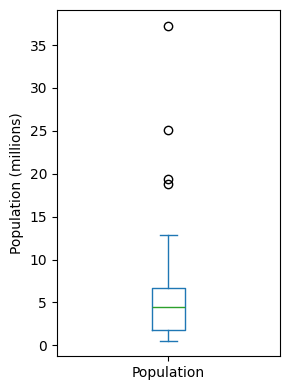

In [16]:
ax = (state['Population']/1_000_000).plot.box(figsize=(3, 4))
ax.set_ylabel('Population (millions)')

plt.tight_layout()
plt.show()

#### 🔎 Cara Membaca Boxplot Populasi

Kotak boxplot terlihat pendek dan berada di bawah, sedangkan ada beberapa titik jauh di atas kumis. Itu adalah **outlier**, yaitu negara bagian dengan penduduk jauh di atas kebanyakan (misalnya California, Texas, New York). Median yang berada di bagian bawah kotak juga menegaskan distribusi yang **miring ke kanan**.

## 📊 Frequency Table & Histogram

A **frequency table** membagi rentang nilai menjadi interval sama lebar (*bin*), lalu menghitung berapa data yang jatuh di tiap bin. **Histogram** adalah gambar dari tabel itu: batang menunjukkan jumlah data per bin.

Poin penting:
- Bin harus **sama lebar**, tetapi jumlahnya boleh berbeda isinya (bin kosong tetap ditampilkan).
- Lebar bin memengaruhi tampilan: terlalu lebar → detail hilang; terlalu sempit → gambar "berisik".
- Dari histogram terlihat **bentuk distribusi**: simetris atau miring, satu puncak (*unimodal*) atau lebih.
- Istilah yang muncul: **skewness** (kemiringan) dan **kurtosis** (ketebalan ekor).

> Beda dengan *bar chart*: bar chart untuk data **kategori**, histogram untuk data **numerik** (batangnya bersentuhan).

In [17]:
binnedPopulation = pd.cut(state['Population'], 10)
print(binnedPopulation.value_counts())

Population
(526935.67, 4232659.0]      24
(4232659.0, 7901692.0]      14
(7901692.0, 11570725.0]      6
(11570725.0, 15239758.0]     2
(15239758.0, 18908791.0]     1
(18908791.0, 22577824.0]     1
(22577824.0, 26246857.0]     1
(33584923.0, 37253956.0]     1
(26246857.0, 29915890.0]     0
(29915890.0, 33584923.0]     0
Name: count, dtype: int64


#### 🔎 Interpretasi Hasil (Tabel Frekuensi Populasi)

Dengan 10 bin, **24 dari 50 negara bagian** berada di bin terendah (±0,5–4,2 juta). Sementara bin ujung atas hanya berisi **1 negara bagian** (California, ±33,6–37,3 juta), dan bin di antaranya bahkan kosong. Inilah bukti visual bahwa distribusi populasi **sangat miring ke kanan**: kebanyakan negara bagian berpenduduk sedikit, dan segelintir sangat besar. Histogram di bawah menampilkan bentuk yang sama.

In [18]:
# Table 1.5
binnedPopulation.name = 'binnedPopulation'
df = pd.concat([state, binnedPopulation], axis=1)
df = df.sort_values(by='Population')

groups = []
for group, subset in df.groupby(by='binnedPopulation', observed=False):
    groups.append({
        'BinRange': group,
        'Count': len(subset),
        'States': ','.join(subset.Abbreviation)
    })
print(pd.DataFrame(groups))

                   BinRange  Count  \
0    (526935.67, 4232659.0]     24   
1    (4232659.0, 7901692.0]     14   
2   (7901692.0, 11570725.0]      6   
3  (11570725.0, 15239758.0]      2   
4  (15239758.0, 18908791.0]      1   
5  (18908791.0, 22577824.0]      1   
6  (22577824.0, 26246857.0]      1   
7  (26246857.0, 29915890.0]      0   
8  (29915890.0, 33584923.0]      0   
9  (33584923.0, 37253956.0]      1   

                                              States  
0  WY,VT,ND,AK,SD,DE,MT,RI,NH,ME,HI,ID,NE,WV,NM,N...  
1          KY,LA,SC,AL,CO,MN,WI,MD,MO,TN,AZ,IN,MA,WA  
2                                  VA,NJ,NC,GA,MI,OH  
3                                              PA,IL  
4                                                 FL  
5                                                 NY  
6                                                 TX  
7                                                     
8                                                     
9                              

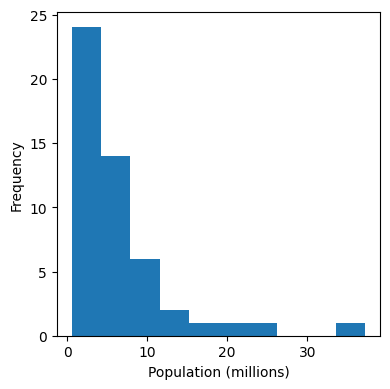

In [19]:
ax = (state['Population'] / 1_000_000).plot.hist(figsize=(4, 4))
ax.set_xlabel('Population (millions)')

plt.tight_layout()
plt.show()

## 🌊 Density Plot & Density Estimate

**Density plot** adalah versi **halus** dari histogram: bukan batang, melainkan kurva kontinu. Sumbu-y berupa *kepadatan* (bukan jumlah), dengan total luas di bawah kurva = 1.

Cara membuatnya: **Kernel Density Estimation (KDE)**. Di tiap titik data diletakkan "gunung kecil" (kernel), lalu semuanya dijumlahkan menjadi satu kurva mulus.

**Keunggulan:**
- Bisa melihat bentuk distribusi lebih jelas, tanpa terganggu pilihan batas bin.
- Mudah ditumpuk di atas histogram, atau dipakai membandingkan beberapa distribusi.
- Parameter **bandwidth** mengatur kehalusan kurva: kecil → bergerigi, besar → terlalu halus.

Pada kode, histogram dibuat dengan `density=True` supaya skala sumbu-y sama dengan kurva KDE, sehingga keduanya bisa ditumpuk.

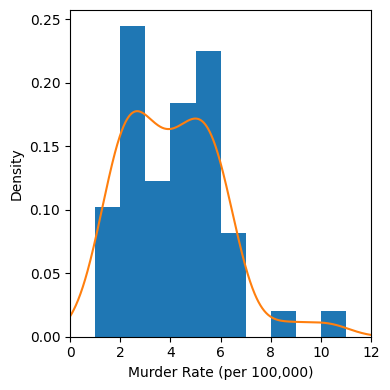

In [20]:
ax = state['Murder.Rate'].plot.hist(density=True, xlim=[0, 12],
                                    bins=range(1,12), figsize=(4, 4))
state['Murder.Rate'].plot.density(ax=ax)
ax.set_xlabel('Murder Rate (per 100,000)')

plt.tight_layout()
plt.show()



#### 🔎 Interpretasi Hasil

Kurva density mengikuti bentuk histogram *murder rate*, tetapi lebih halus. Terlihat bahwa sebagian besar negara bagian memiliki angka di kisaran rendah-menengah (sekitar 2–6 per 100.000), dengan ekor tipis ke arah angka yang lebih tinggi.

## 🧮 Exploring Binary and Categorical Data

Untuk data kategori kita tidak bisa menghitung mean, jadi yang dilihat adalah:
- **Mode** — kategori yang paling sering muncul.
- **Proporsi / persentase** tiap kategori.
- **Expected value** — rata-rata berbobot dari kategori yang diberi nilai numerik: $E = \sum_i x_i p_i$.

Data **biner** (0/1, ya/tidak) adalah kasus khusus; rata-ratanya = proporsi kejadian "1". Divisualisasikan dengan **bar chart** (bukan histogram).

Di bawah, kita melihat penyebab keterlambatan pesawat di bandara DFW per kategori (carrier, ATC, cuaca, keamanan, pesawat sebelumnya).

In [21]:

dfw = pd.read_csv('dfw_airline.csv')
dfw

,Carrier,ATC,Weather,Security,Inbound
0,64263.16,84856.5,11235.42,343.15,118427.82


In [22]:
print(100 * dfw / dfw.values.sum())

     Carrier        ATC   Weather  Security    Inbound
0  23.022989  30.400781  4.025214  0.122937  42.428079


#### 🔎 Interpretasi Hasil (Penyebab Keterlambatan di Bandara DFW)

| Penyebab | Persentase |
|---|---|
| Inbound (pesawat sebelumnya terlambat) | ≈ 42,4% |
| ATC (kontrol lalu lintas udara) | ≈ 30,4% |
| Carrier (maskapai) | ≈ 23,0% |
| Weather (cuaca) | ≈ 4,0% |
| Security (keamanan) | ≈ 0,12% |

**Mode** (kategori paling sering) adalah *Inbound*. Bar chart di bawah menampilkan proporsi ini. Hampir 3/4 keterlambatan berasal dari efek berantai pesawat sebelumnya dan ATC, sedangkan faktor keamanan nyaris tidak berpengaruh.

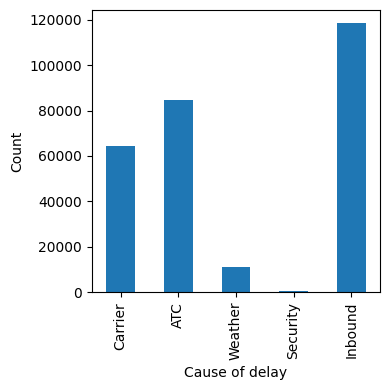

In [23]:
ax = dfw.transpose().plot.bar(figsize=(4, 4), legend=False)
ax.set_xlabel('Cause of delay')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

## 🔗 Korelasi

**Koefisien korelasi Pearson** mengukur kekuatan hubungan **linear** antara dua variabel numerik:

$$ r = \frac{\sum (x_i-\bar{x})(y_i-\bar{y})}{(n-1)\, s_x s_y} $$

| Nilai $r$ | Arti |
|---|---|
| mendekati **+1** | Hubungan positif kuat (x naik → y naik) |
| mendekati **−1** | Hubungan negatif kuat (x naik → y turun) |
| mendekati **0** | Tidak ada hubungan *linear* |

⚠️ **Peringatan penting:**
1. **Korelasi ≠ sebab-akibat.**
2. Pearson sensitif terhadap outlier; alternatifnya **Spearman/Kendall** (berbasis peringkat).
3. $r \approx 0$ tidak berarti tidak ada hubungan sama sekali (hubungan non-linear bisa tidak terdeteksi).

**Correlation matrix** menampilkan korelasi semua pasangan variabel sekaligus (di sini: return harga saham ETF/telekomunikasi). Heatmap/ellipse memudahkan melihat kelompok saham yang bergerak bersama.

In [24]:
sp500_sym = pd.read_csv('sp500_sectors.csv')
sp500_px = pd.read_csv('sp500_data.csv.gz', index_col=0)

In [25]:
# Table 1-7
# Determine telecommunications symbols
telecomSymbols = sp500_sym[sp500_sym['sector'] == 'telecommunications_services']['symbol']

# Filter data for dates July 2012 through June 2015
telecom = sp500_px.loc[sp500_px.index >= '2012-07-01', telecomSymbols]
telecom.corr()
print(telecom)

                   T       CTL       FTR        VZ      LVLT
2012-07-02  0.422496  0.140847  0.070879  0.554180 -0.519998
2012-07-03 -0.177448  0.066280  0.070879 -0.025976 -0.049999
2012-07-05 -0.160548 -0.132563  0.055128 -0.051956 -0.180000
2012-07-06  0.342205  0.132563  0.007875  0.140106 -0.359999
2012-07-09  0.136883  0.124279 -0.023626  0.253943  0.180000
...              ...       ...       ...       ...       ...
2015-06-25  0.049342 -1.600000 -0.040000 -0.187790 -0.330002
2015-06-26 -0.256586  0.039999 -0.070000  0.029650 -0.739998
2015-06-29 -0.098685 -0.559999 -0.060000 -0.504063 -1.360000
2015-06-30 -0.503298 -0.420000 -0.070000 -0.523829  0.199997
2015-07-01 -0.019737  0.080000 -0.050000  0.355811  0.139999

[754 rows x 5 columns]


In [26]:
etfs = sp500_px.loc[sp500_px.index > '2012-07-01',
                    sp500_sym[sp500_sym['sector'] == 'etf']['symbol']]
print(etfs.head())

                 XLI       QQQ       SPY       DIA       GLD    VXX       USO  \
2012-07-02 -0.376098  0.096313  0.028223 -0.242796  0.419998 -10.40  0.000000   
2012-07-03  0.376099  0.481576  0.874936  0.728405  0.490006  -3.52  0.250000   
2012-07-05  0.150440  0.096313 -0.103487  0.149420  0.239991   6.56 -0.070000   
2012-07-06 -0.141040 -0.491201  0.018819 -0.205449 -0.519989  -8.80 -0.180000   
2012-07-09  0.244465 -0.048160 -0.056445 -0.168094  0.429992  -0.48  0.459999   

                 IWM       XLE       XLY       XLU       XLB       XTL  \
2012-07-02  0.534641  0.028186  0.095759  0.098311 -0.093713  0.019076   
2012-07-03  0.926067  0.995942  0.000000 -0.044686  0.337373  0.000000   
2012-07-05 -0.171848 -0.460387  0.306431 -0.151938  0.103086  0.019072   
2012-07-06 -0.229128  0.206706  0.153214  0.080437  0.018744 -0.429213   
2012-07-09 -0.190939 -0.234892 -0.201098 -0.035751 -0.168687  0.000000   

                 XLV       XLP       XLF       XLK  
2012-07-02 -0.0

#### 🌡️ Correlation Matrix & Heatmap

Tabel *return* harga saham punya banyak kolom, sehingga matriks korelasinya sulit dibaca dalam bentuk angka. Solusinya **heatmap**: setiap sel diwarnai menurut nilai korelasi.

**Cara membaca heatmap di bawah:** `vmin=-1` dan `vmax=1` membuat skala warna menutupi seluruh rentang korelasi. Warna **biru** menunjukkan korelasi **positif**, **oranye/merah** menunjukkan korelasi **negatif**, dan warna **terang/putih** berarti hampir tidak berkorelasi. Diagonal selalu paling pekat (korelasi sebuah variabel dengan dirinya sendiri = 1).

Kelompok ETF yang sejenis (misalnya yang melacak sektor sama) akan terlihat saling berkorelasi tinggi.

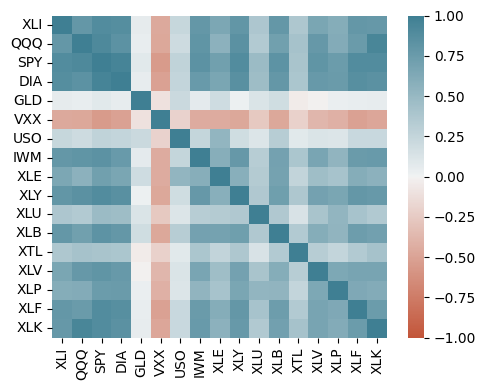

In [27]:
fig, ax = plt.subplots(figsize=(5, 4))
ax = sns.heatmap(etfs.corr(), vmin=-1, vmax=1,
                 cmap=sns.diverging_palette(20, 220, as_cmap=True),
                 ax=ax)

plt.tight_layout()
plt.show()

#### ⭕ Ellipse Plot (Alternatif untuk Gambar Hitam-Putih)

Buku asli dicetak hitam-putih, sehingga warna tidak bisa dipakai. Pada versi ini kekuatan dan arah korelasi ditunjukkan dengan **elips**:
- **Elips tipis/sempit** → korelasi kuat; **elips hampir bulat** → korelasi lemah.
- **Kemiringan** elips (naik ke kanan atau turun ke kanan) menunjukkan korelasi **positif atau negatif**.

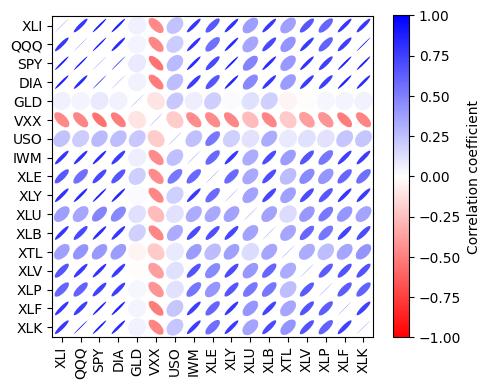

In [28]:
from matplotlib.collections import EllipseCollection
from matplotlib.colors import Normalize

def plot_corr_ellipses(data, figsize=None, **kwargs):
    ''' https://stackoverflow.com/a/34558488 '''
    M = np.array(data)
    if not M.ndim == 2:
        raise ValueError('data must be a 2D array')
    fig, ax = plt.subplots(1, 1, figsize=figsize, subplot_kw={'aspect':'equal'})
    ax.set_xlim(-0.5, M.shape[1] - 0.5)
    ax.set_ylim(-0.5, M.shape[0] - 0.5)
    ax.invert_yaxis()

    # xy locations of each ellipse center
    xy = np.indices(M.shape)[::-1].reshape(2, -1).T

    # set the relative sizes of the major/minor axes according to the strength of
    # the positive/negative correlation
    w = np.ones_like(M).ravel() + 0.01
    h = 1 - np.abs(M).ravel() - 0.01
    a = 45 * np.sign(M).ravel()

    ec = EllipseCollection(widths=w, heights=h, angles=a, units='x', offsets=xy,
                           norm=Normalize(vmin=-1, vmax=1),
                           transOffset=ax.transData, array=M.ravel(), **kwargs)
    ax.add_collection(ec)

    # if data is a DataFrame, use the row/column names as tick labels
    if isinstance(data, pd.DataFrame):
        ax.set_xticks(np.arange(M.shape[1]))
        ax.set_xticklabels(data.columns, rotation=90)
        ax.set_yticks(np.arange(M.shape[0]))
        ax.set_yticklabels(data.index)

    return ec, ax

m, ax = plot_corr_ellipses(etfs.corr(), figsize=(5, 4), cmap='bwr_r')
cb = plt.colorbar(m, ax=ax)
cb.set_label('Correlation coefficient')

plt.tight_layout()
plt.show()



## ⚫ Scatter Plot

**Scatter plot** menggambar setiap observasi sebagai titik $(x, y)$. Dari sini kita lihat langsung:
- arah hubungan (naik/turun),
- kekuatan (titik rapat atau menyebar),
- bentuk (linear / melengkung),
- outlier.

Cocok untuk data berukuran kecil sampai ratusan titik. Untuk data besar, titik saling menumpuk → gunakan hexbin/contour (bagian berikutnya).

**Contoh di bawah:** return harian saham **AT&T (T)** vs **Verizon (VZ)**. Titik-titik membentuk pola naik dari kiri-bawah ke kanan-atas, artinya kalau saham AT&T naik, Verizon cenderung ikut naik (korelasi positif), wajar karena keduanya perusahaan telekomunikasi. Garis abu-abu di 0 menandai batas antara return positif dan negatif.

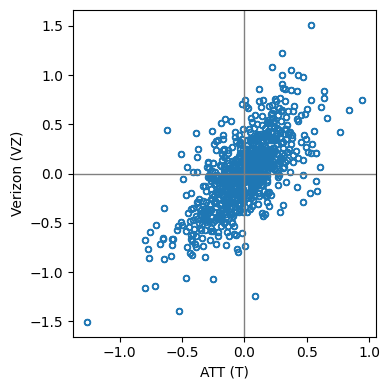

In [29]:
ax = telecom.plot.scatter(x='T', y='VZ', figsize=(4, 4), marker='$\u25EF$')
ax.set_xlabel('ATT (T)')
ax.set_ylabel('Verizon (VZ)')
ax.axhline(0, color='grey', lw=1)
ax.axvline(0, color='grey', lw=1)

plt.tight_layout()
plt.show()

## 🔀 Exploring Two or More Variables

Sejauh ini kita melihat satu variabel (**univariate**). Pada **bivariate / multivariate analysis** kita melihat beberapa variabel sekaligus. Pilihan alat bergantung pada tipe datanya:

| Tipe variabel | Alat |
|---|---|
| Numerik vs numerik | Scatter plot, **hexagonal binning**, **contour plot** |
| Kategori vs kategori | **Tabel kontingensi** (contingency table) |
| Kategori vs numerik | **Boxplot**, **violin plot** |
| Banyak variabel | **Conditioning / facet** (grafik dipecah per kategori) |

In [30]:

kc_tax = pd.read_csv('kc_tax.csv.gz')
kc_tax0 = kc_tax.loc[(kc_tax.TaxAssessedValue < 750000) &
                     (kc_tax.SqFtTotLiving > 100) &
                     (kc_tax.SqFtTotLiving < 3500), :]
print(kc_tax0.shape)

(432693, 3)


#### ⬡ Hexagonal Binning & Contour Plot

Jika jumlah titik sangat besar, scatter plot menjadi **gumpalan hitam** karena titik saling menutupi (*overplotting*) dan tidak informatif lagi. Metode yang menampilkan **kepadatan** lebih berguna:

- **Hexagonal binning:** bidang dibagi menjadi segi enam; warna menunjukkan **jumlah titik** di tiap segi enam (makin pekat → makin banyak data).
- **Contour plot (2D KDE):** garis kontur menggambarkan kepadatan, seperti peta topografi. Puncak "bukit" adalah kombinasi nilai yang paling umum.

**Data:** `kc_tax` (pajak properti King County). Setelah disaring (nilai pajak < 750.000 dan luas bangunan 100–3500 sq ft) tersisa **432.693 rumah**. Hubungannya: *luas bangunan* (`SqFtTotLiving`) vs *nilai taksiran pajak* (`TaxAssessedValue`).

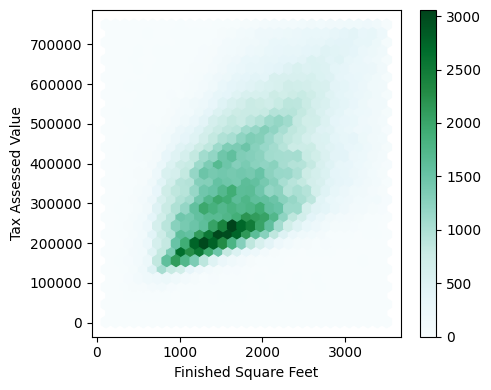

In [31]:
ax = kc_tax0.plot.hexbin(x='SqFtTotLiving', y='TaxAssessedValue',
                         gridsize=30, sharex=False, figsize=(5, 4))
ax.set_xlabel('Finished Square Feet')
ax.set_ylabel('Tax Assessed Value')

plt.tight_layout()
plt.show()

Contour plot dari `seaborn.kdeplot` adalah perluasan density plot ke **dua dimensi**. Menghitung kepadatan untuk seluruh 432 ribu data bisa memakan waktu beberapa menit, jadi cukup memakai **sampel 10.000 titik**: bentuk keseluruhan tetap terjaga walau sedikit detail hilang.

**Cara membaca:** kontur yang rapat dan tertutup di tengah menandakan area dengan kepadatan data tertinggi, yaitu rumah ±1.500–2.500 sq ft dengan nilai pajak menengah.

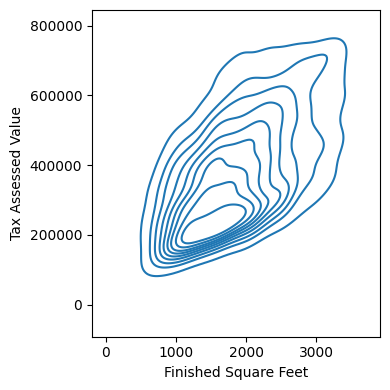

In [32]:
fig, ax = plt.subplots(figsize=(4, 4))
sns.kdeplot(data=kc_tax0.sample(10000), x='SqFtTotLiving', y='TaxAssessedValue', ax=ax)
ax.set_xlabel('Finished Square Feet')
ax.set_ylabel('Tax Assessed Value')

plt.tight_layout()
plt.show()

#### 📋 Two Categorical Variables: Tabel Kontingensi

**Contingency table** adalah tabel frekuensi silang dua variabel kategori. Contoh: *grade* pinjaman (A–G) × *status* pinjaman (lunas, gagal bayar, dll.).

Biasanya ditampilkan sebagai **jumlah** dan **persentase baris**. Dari sini kita bisa menilai apakah grade yang buruk memang berasosiasi dengan gagal bayar lebih tinggi.

In [33]:
lc_loans = pd.read_csv('lc_loans.csv')
lc_loans

,status,grade
0,Fully Paid,B
1,Charged Off,C
2,Fully Paid,C
3,Fully Paid,C
4,Current,B
...,...,...
450956,Current,D
450957,Current,D
450958,Current,D
450959,Current,D


In [34]:

crosstab = lc_loans.pivot_table(index='grade', columns='status',
                                aggfunc=lambda x: len(x), margins=True)
print(crosstab)

status  Charged Off  Current  Fully Paid  Late     All
grade                                                 
A              1562    50051       20408   469   72490
B              5302    93852       31160  2056  132370
C              6023    88928       23147  2777  120875
D              5007    53281       13681  2308   74277
E              2842    24639        5949  1374   34804
F              1526     8444        2328   606   12904
G               409     1990         643   199    3241
All           22671   321185       97316  9789  450961


In [35]:
df = crosstab.copy().loc['A':'G',:].astype(float)
df.loc[:,'Charged Off':'Late'] = df.loc[:,'Charged Off':'Late'].div(df['All'], axis=0)
df['All'] = df['All'] / sum(df['All'])
perc_crosstab = df
print(perc_crosstab)


status  Charged Off   Current  Fully Paid      Late       All
grade                                                        
A          0.021548  0.690454    0.281528  0.006470  0.160746
B          0.040054  0.709013    0.235401  0.015532  0.293529
C          0.049828  0.735702    0.191495  0.022974  0.268039
D          0.067410  0.717328    0.184189  0.031073  0.164708
E          0.081657  0.707936    0.170929  0.039478  0.077177
F          0.118258  0.654371    0.180409  0.046962  0.028614
G          0.126196  0.614008    0.198396  0.061401  0.007187


#### 🔎 Interpretasi Hasil (Grade vs Status Pinjaman)

Tabel pertama adalah **jumlah** pinjaman per grade dan status; tabel kedua adalah **proporsi per baris** (setiap grade berjumlah 100%). Lihat kolom *Charged Off* (gagal bayar):

| Grade | A | B | C | D | E | F | G |
|---|---|---|---|---|---|---|---|
| % Charged Off | 2,2% | 4,0% | 5,0% | 6,7% | 8,2% | 11,8% | 12,6% |

**Semakin rendah grade pinjaman, semakin tinggi proporsi gagal bayar**: grade G sekitar 6 kali lipat grade A. Ini membuktikan bahwa grade memang berasosiasi dengan risiko kredit. Kolom `All` pada tabel kedua menunjukkan porsi tiap grade terhadap total pinjaman (grade B terbanyak, ±29%).

#### 📦 Categorical and Numeric Data: Boxplot per Kategori

Untuk membandingkan distribusi variabel numerik antar kategori:
- **Boxplot per kategori** — membandingkan median, IQR, dan outlier tiap grup.
- **Violin plot** — seperti boxplot tapi juga menampilkan **bentuk kepadatan** (density) sehingga terlihat jika distribusinya bimodal.

Di sini: persentase keterlambatan penerbangan per maskapai.

**Contoh:** persentase penerbangan terlambat harian karena maskapai (`pct_carrier_delay`) untuk beberapa maskapai. Bandingkan posisi median dan lebar kotak antar maskapai untuk menilai maskapai mana yang lebih sering/stabil terlambat.

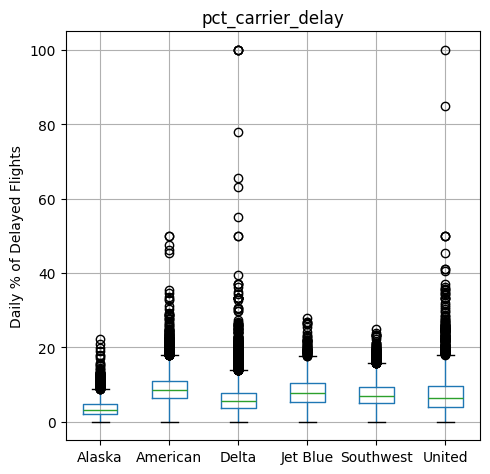

In [36]:
airline_stats = pd.read_csv('airline_stats.csv')
airline_stats.head()
ax = airline_stats.boxplot(by='airline', column='pct_carrier_delay',
                           figsize=(5, 5))
ax.set_xlabel('')
ax.set_ylabel('Daily % of Delayed Flights')
plt.suptitle('')

plt.tight_layout()
plt.show()

#### 🎻 Violin Plot

**Violin plot** (diperkenalkan Hintze & Nelson, 1998) adalah pengembangan boxplot: sumbu-y menampilkan **estimasi density**, dicerminkan ke kiri-kanan sehingga bentuknya seperti biola. Garis `quartile` di dalamnya menandai Q1, median, dan Q3.

**Kelebihannya:** memperlihatkan **bentuk distribusi** (mis. bimodal) yang tersembunyi di boxplot. Dua distribusi bisa punya boxplot hampir sama, tapi violin-nya berbeda. Bagian yang melebar = banyak data di nilai tersebut.

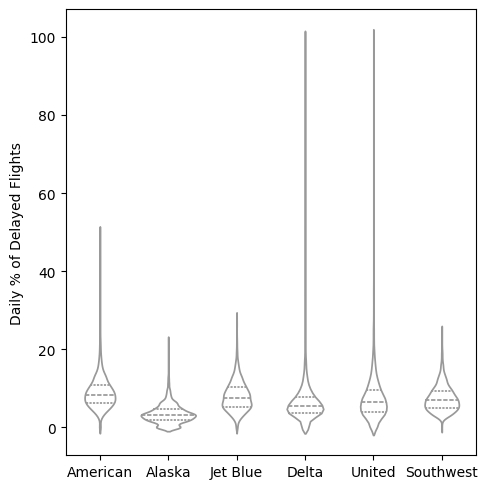

In [37]:
fig, ax = plt.subplots(figsize=(5, 5))
sns.violinplot(data=airline_stats, x='airline', y='pct_carrier_delay',
               ax=ax, inner='quartile', color='white')
ax.set_xlabel('')
ax.set_ylabel('Daily % of Delayed Flights')

plt.tight_layout()
plt.show()

#### 🧩 Visualizing Multiple Variables (Conditioning / Faceting)

Dengan **conditioning (faceting)**, satu grafik dipecah menjadi beberapa panel berdasarkan variabel kategori ketiga. Misalnya hubungan *luas rumah vs nilai pajak* digambar terpisah untuk tiap **kode pos**. Ini cara mudah menampilkan **3+ variabel** dalam grafik 2D dan memperlihatkan bahwa hubungan bisa berbeda antar kelompok.

**Contoh:** hubungan luas rumah vs nilai pajak dipisah per **kode pos** (98188, 98105, 98108, 98126) dengan `FacetGrid`. Terlihat bahwa kemiringan hubungan dan sebaran nilai berbeda antar kode pos, yaitu faktor lokasi memengaruhi harga.

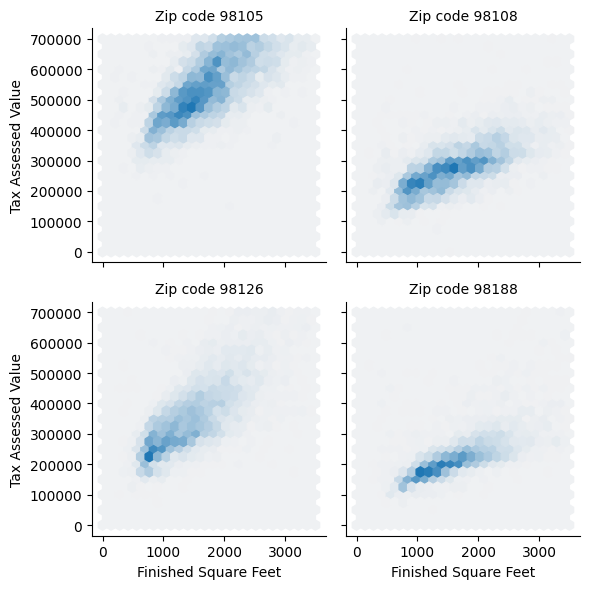

In [38]:
zip_codes = [98188, 98105, 98108, 98126]
kc_tax_zip = kc_tax0.loc[kc_tax0.ZipCode.isin(zip_codes),:]
kc_tax_zip

def hexbin(x, y, color, **kwargs):
    cmap = sns.light_palette(color, as_cmap=True)
    plt.hexbin(x, y, gridsize=25, cmap=cmap, **kwargs)

g = sns.FacetGrid(kc_tax_zip, col='ZipCode', col_wrap=2)
g.map(hexbin, 'SqFtTotLiving', 'TaxAssessedValue',
      extent=[0, 3500, 0, 700000])
g.set_axis_labels('Finished Square Feet', 'Tax Assessed Value')
g.set_titles('Zip code {col_name:.0f}')

plt.tight_layout()
plt.show()
